In [1]:
# # Publication Plots for MigNar Paper
# 
# This notebook generates publication-quality plots from the pre-computed monthly aggregates.
# These complement the interactive Streamlit dashboards with static, paper-ready visualizations.

# %%
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime
import seaborn as sns
from dotenv import load_dotenv

load_dotenv()

# Set publication-quality plot defaults
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 10
plt.rcParams['font.family'] = 'serif'
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['xtick.labelsize'] = 9
plt.rcParams['ytick.labelsize'] = 9
plt.rcParams['legend.fontsize'] = 9
plt.rcParams['figure.titlesize'] = 13

# Color palette for domains
DOMAIN_COLORS = {
    'UK Parliament (Con)': '#0087DC',  # Conservative blue
    'UK Parliament (Lab)': '#E4003B',  # Labour red
    'US Congress (Rep)': '#E81B23',    # Republican red
    'US Congress (Dem)': '#0015BC',    # Democrat blue
}

# Define domains to exclude (parliamentary/congressional)
EXCLUDE_DOMAINS = [
    'UK Parliament (Lab)',
    'UK Parliament (Con)',
    'UK Parliament (Reform)',
    'UK Parliament (LD)',
    'UK Parliament (SNP)',
    'UK Parliament (Green)',
    'UK Parliament (All)',
    'US Congress (Rep)',
    'US Congress (Dem)',
    'US Congress (All)'
]


# Output directory for plots
OUTPUT_DIR = os.path.expanduser("./plots_for_paper")

# Data directory
DATA_DIR = os.path.expanduser("./data")

# %%
# Load monthly aggregates
STANCE_PATH = os.path.join(DATA_DIR, "stance_monthly.parquet")
THEMES_PATH = os.path.join(DATA_DIR, "themes_monthly.parquet")
MESO_PATH   = os.path.join(DATA_DIR, "meso_monthly.parquet")

def load_parquet(fp: str) -> pd.DataFrame:
    """Load parquet file and prepare columns"""
    if not os.path.exists(fp):
        print(f"Warning: {fp} not found")
        return pd.DataFrame()
    
    df = pd.read_parquet(fp)
    
    # Convert month string to datetime
    if "month" in df.columns:
        df["month"] = pd.to_datetime(df["month"] + "-01", errors="coerce")
    
    # Ensure categorical columns are strings
    for col in ["source_domain", "model", "stance", "theme", "meso_narrative"]:
        if col in df.columns:
            df[col] = df[col].fillna("").astype(str)
    
    # Ensure count is numeric
    if "count" in df.columns:
        df["count"] = pd.to_numeric(df["count"], errors="coerce").fillna(0).astype(int)
    
    return df

stance_df = load_parquet(STANCE_PATH)
themes_df = load_parquet(THEMES_PATH)
meso_df = load_parquet(MESO_PATH)

print(f"Loaded data:")
print(f"  Stance: {len(stance_df):,} rows")
print(f"  Themes: {len(themes_df):,} rows")
print(f"  Meso: {len(meso_df):,} rows")

Loaded data:
  Stance: 179,923 rows
  Themes: 1,924,234 rows
  Meso: 3,688,603 rows


# Summary Text vs. Full Text Robustness

In [1]:
# This table compares the theme and meso narrative extractions from Perigon's AI-generated summaries 
# versus the scraped full-body HTML texts for a 1,000-article sample.

import os
import sqlite3
import pandas as pd
import json
import numpy as np
from collections import Counter
from scipy.spatial.distance import jensenshannon
from dotenv import load_dotenv
from IPython.display import display

# Import Taxonomy for Strict Output Filtering
from taxonomy.meso_narratives_revision_2 import mesoNarratives

load_dotenv()
DB_PATH = os.getenv("SQLITE_PATH")

# --- CUSTOMIZATION MACROS ---
# Define what percentage of the most frequent labels to keep (1.0 = 100%, 0.5 = Top 50%)
TOP_PERCENT_THEMES = 1.0  
TOP_PERCENT_MESO = 1.0  
# TOP_PERCENT_THEMES = 0.1
# TOP_PERCENT_MESO = 0.1
N_BOOTSTRAPS = 100 # Number of iterations for the random split JS baseline
# ---------------------------

# Set seed for reproducible bootstrapping
np.random.seed(42)

# Build exact lookup structures based on taxonomy
VALID_THEMES = set(mesoNarratives.keys())
VALID_MESO_PAIRS = set()
for theme, items in mesoNarratives.items():
    if isinstance(items, list):
        for item in items:
            if isinstance(item, list) and len(item) >= 2:
                VALID_MESO_PAIRS.add((theme, item[0].strip()))

def fetch_paired_annotations(conn, task):
    """Fetches annotations for the same articles across summary and full text."""
    query = f"""
    SELECT 
        l.article_id,
        l.model,
        l.is_on_full_text,
        l.annotation_parsed
    FROM llm_annotations l
    JOIN articles a ON l.article_id = a.article_id
    WHERE a.full_body_collected = 1
      AND l.source_table = 'articles'
      AND l.task = '{task}'
      AND l.version = 2
      AND l.annotation_parsed IS NOT NULL
    """
    return pd.read_sql_query(query, conn)

def parse_annotation_array(val, task):
    if not val: return set()
    try:
        arr = json.loads(val)
        if not isinstance(arr, list): return set()
        
        if task == 'themes':
            res = set()
            for x in arr:
                if isinstance(x, str):
                    t = str(x).strip()
                    # Enforce strict taxonomy constraint
                    if t in VALID_THEMES:
                        res.add(t)
            return res
            
        elif task == 'meso':
            res = set()
            for o in arr:
                if isinstance(o, dict):
                    t = str(o.get('narrative theme', '')).strip()
                    m = str(o.get('meso narrative', '')).strip()
                    # Enforce strict taxonomy constraint (exact meso paired with its correct theme)
                    if t and m and (t, m) in VALID_MESO_PAIRS:
                        res.add((t, m)) # Tuple of (Theme, Meso)
            return res
    except:
        return set()
    return set()

def distribution_divergence_stats(model_rows):
    """Calculate the JS Divergence between summary and full text overall distributions."""
    sum_counts = Counter()
    full_counts = Counter()

    for _, row in model_rows.iterrows():
        sum_counts.update(row['Summary'])
        full_counts.update(row['Full Text'])

    if not sum_counts and not full_counts:
        return np.nan
        
    # Align vectors
    keys = sorted(set(sum_counts) | set(full_counts))
    obs_sum = np.array([sum_counts.get(k, 0) for k in keys], dtype=float)
    obs_full = np.array([full_counts.get(k, 0) for k in keys], dtype=float)

    sum_total, full_total = obs_sum.sum(), obs_full.sum()
    if sum_total == 0 or full_total == 0:
        return np.nan

    # Convert to probabilities
    p_sum = obs_sum / sum_total
    p_full = obs_full / full_total

    # Jensen-Shannon (0 = identical, 1 = completely disjoint)
    return jensenshannon(p_sum, p_full)

# Process metrics
results = []
MODELS = ['gpt-oss-20b', 'Qwen3-32B', 'gemma-3-27b-it', 'Kimi-Linear-48B-A3B-Instruct']

with sqlite3.connect(DB_PATH) as conn:
    for task in ['themes', 'meso']:
        df = fetch_paired_annotations(conn, task)
        if df.empty:
            continue
            
        df['parsed_set'] = df.apply(lambda row: parse_annotation_array(row['annotation_parsed'], task), axis=1)
        df['type'] = df['is_on_full_text'].apply(lambda x: 'Full Text' if x == 1 else 'Summary')
        
        # Determine Top K Allowed Items based on Global Full-Text Frequencies
        percent_to_keep = TOP_PERCENT_THEMES if task == 'themes' else TOP_PERCENT_MESO
        global_counts = Counter()
        for _, row in df[df['type'] == 'Full Text'].iterrows():
            global_counts.update(row['parsed_set'])
            
        num_to_keep = max(1, int(len(global_counts) * percent_to_keep))
        allowed_items = set([item for item, count in global_counts.most_common(num_to_keep)])
        
        # Build Ensemble Model predictions (>= 2 models predicting the same item per article per type)
        ensemble_rows = []
        for (aid, type_), group in df.groupby(['article_id', 'type']):
            item_counts = Counter()
            for items in group['parsed_set']:
                item_counts.update(items)
            
            ensemble_set = {item for item, count in item_counts.items() if count >= 2}
            ensemble_rows.append({
                'article_id': aid,
                'model': 'Ensemble',
                'type': type_,
                'parsed_set': ensemble_set
            })
            
        df = pd.concat([df, pd.DataFrame(ensemble_rows)], ignore_index=True)
        extended_models = MODELS + ['Ensemble']
        
        # Pivot so we have Summary and Full Text columns side-by-side per article+model
        pivot = df.pivot_table(
            index=['article_id', 'model'], 
            columns='type', 
            values='parsed_set', 
            aggfunc='first'
        ).dropna() # Drop pairs that don't have BOTH summary and full text runs
        
        if pivot.empty: 
            continue
            
        for model in extended_models:
            if model not in pivot.index.get_level_values('model'): 
                continue
                
            model_data = pivot.xs(model, level='model').copy()
            
            # 1. Apply Top % Filter and drop pairs where Full Text has nothing left
            filtered_rows = []
            for _, row in model_data.iterrows():
                top_sum = row['Summary'].intersection(allowed_items)
                top_full = row['Full Text'].intersection(allowed_items)
                
                if len(top_full) == 0:
                    continue
                
                row['Summary'] = top_sum
                row['Full Text'] = top_full
                filtered_rows.append(row)
                
            if not filtered_rows:
                continue
                
            model_data = pd.DataFrame(filtered_rows)
            
            jaccards, recalls = [], []
            for _, row in model_data.iterrows():
                set_sum, set_full = row['Summary'], row['Full Text']
                union, inter = set_sum.union(set_full), set_sum.intersection(set_full)
                
                # Jaccard (Similarity)
                jaccards.append(len(inter) / len(union) if len(union) > 0 else 1.0)
                    
                # Recall
                recalls.append(len(inter) / len(set_full) if len(set_full) > 0 else 1.0)
                        
            # 2. Distribution checks (Jensen-Shannon)
            js_div = distribution_divergence_stats(model_data)

            # 3. Bootstrapping Baseline JS Noise (Random 50/50 Splits of Full Text)
            full_texts = model_data['Full Text'].tolist()
            bs_js_scores = []
            
            for _ in range(N_BOOTSTRAPS):
                shuffled_full = list(full_texts)
                np.random.shuffle(shuffled_full)
                half = len(shuffled_full) // 2
                
                counts_a, counts_b = Counter(), Counter()
                for s in shuffled_full[:half]: counts_a.update(s)
                for s in shuffled_full[half:]: counts_b.update(s)
                
                keys_ab = sorted(set(counts_a) | set(counts_b))
                obs_a = np.array([counts_a.get(k, 0) for k in keys_ab], dtype=float)
                obs_b = np.array([counts_b.get(k, 0) for k in keys_ab], dtype=float)
                
                if obs_a.sum() > 0 and obs_b.sum() > 0:
                    p_a = obs_a / obs_a.sum()
                    p_b = obs_b / obs_b.sum()
                    bs_js_scores.append(jensenshannon(p_a, p_b))
            
            if bs_js_scores:
                mean_js = np.mean(bs_js_scores)
                ci_lower = np.percentile(bs_js_scores, 2.5)
                ci_upper = np.percentile(bs_js_scores, 97.5)
                baseline_js_str = f"{mean_js:.3f} [{ci_lower:.3f}, {ci_upper:.3f}]"
            else:
                baseline_js_str = "N/A"

            results.append({
                'Model': model,
                'Task': task.capitalize(),
                'N Pairs': len(model_data),
                'Jaccard Similarity (%)': round(np.mean(jaccards) * 100, 3),
                'Summary Recall (%)': round(np.mean(recalls) * 100, 3),
                'JS Divergence': round(js_div, 3) if not np.isnan(js_div) else np.nan,
                'Baseline JS (95% CI)': baseline_js_str
            })

if results:
    results_df = pd.DataFrame(results)
    
    # Pivot for clean paper-style table
    columns_order = ['Summary Recall (%)', 'Jaccard Similarity (%)', 'JS Divergence', 'Baseline JS (95% CI)']
    paper_table = results_df.pivot(index='Model', columns='Task', values=columns_order)
    
    # Flatten multi-indexed columns
    paper_table.columns = [f"{col[1]} - {col[0]}" for col in paper_table.columns]
    
    # Order the rows ensuring Ensemble goes last
    row_order = [m for m in MODELS if m in paper_table.index]
    if 'Ensemble' in paper_table.index:
         row_order.append('Ensemble')
    paper_table = paper_table.loc[row_order]
    
    print("=== Robustness: Summary vs. Full Text (Taxonomy-Filtered) ===")
    print(f"Filters Active: Top {TOP_PERCENT_THEMES * 100:.0f}% Themes | Top {TOP_PERCENT_MESO * 100:.0f}% Meso Narratives | {N_BOOTSTRAPS} Bootstrap Iterations")
    print("Interpretation:")
    print(" - Summary Recall: % of narratives extracted from summary that are also validated by full text (Ideally higher).")
    print(" - JS Divergence: Distance between expected distributions (0 = identical distributions, 1 = completely disjoint distributions).")
    print(" - Baseline JS (95% CI): Expected divergence from randomly splitting the full text in half. JS Divergence should ideally fall within or near this interval!\n")
    display(paper_table)
else:
    print("No paired summary/full-text annotations found in the database yet.")

=== Robustness: Summary vs. Full Text (Taxonomy-Filtered) ===
Filters Active: Top 100% Themes | Top 100% Meso Narratives | 100 Bootstrap Iterations
Interpretation:
 - Summary Recall: % of narratives extracted from summary that are also validated by full text (Ideally higher).
 - JS Divergence: Distance between expected distributions (0 = identical distributions, 1 = completely disjoint distributions).
 - Baseline JS (95% CI): Expected divergence from randomly splitting the full text in half. JS Divergence should ideally fall within or near this interval!



,Meso - Summary Recall (%),Themes - Summary Recall (%),Meso - Jaccard Similarity (%),Themes - Jaccard Similarity (%),Meso - JS Divergence,Themes - JS Divergence,Meso - Baseline JS (95% CI),Themes - Baseline JS (95% CI)
Model,,,,,,,,
gpt-oss-20b,25.574,37.436,20.392,29.529,0.198,0.091,"0.238 [0.223, 0.253]","0.040 [0.032, 0.048]"
Qwen3-32B,25.299,48.766,20.167,40.785,0.151,0.087,"0.109 [0.102, 0.116]","0.030 [0.023, 0.036]"
gemma-3-27b-it,25.735,52.429,20.196,43.925,0.155,0.086,"0.092 [0.085, 0.097]","0.027 [0.021, 0.033]"
Kimi-Linear-48B-A3B-Instruct,25.796,46.345,17.321,37.263,0.153,0.116,"0.123 [0.114, 0.132]","0.028 [0.023, 0.034]"
Ensemble,31.459,56.274,24.232,46.768,0.145,0.086,"0.134 [0.126, 0.142]","0.030 [0.024, 0.037]"


In [4]:
import sqlite3
import pandas as pd
from collections import Counter
from IPython.display import display

# Relies strictly on the globally registered fetch_paired_annotations()
# and parsing function from the above cell which applies the 
# VALID_THEMES and VALID_MESO_PAIRS constraints.

with sqlite3.connect(DB_PATH) as conn:
    for task in ['themes', 'meso']:
        df = fetch_paired_annotations(conn, task)
        if df.empty:
            continue
            
        df['parsed_set'] = df.apply(lambda row: parse_annotation_array(row['annotation_parsed'], task), axis=1)
        df['type'] = df['is_on_full_text'].apply(lambda x: 'Full Text' if x == 1 else 'Summary')
        
        # Build Ensemble Model dynamically
        ensemble_rows = []
        for (aid, type_), group in df.groupby(['article_id', 'type']):
            item_counts = Counter()
            for items in group['parsed_set']:
                item_counts.update(items)
            # Ensemble logic: >= 2 models agree
            ensemble_set = {item for item, count in item_counts.items() if count >= 2}
            ensemble_rows.append({'article_id': aid, 'type': type_, 'parsed_set': ensemble_set})
            
        ens_df = pd.DataFrame(ensemble_rows)
        
        pivot = ens_df.pivot_table(
            index='article_id', columns='type', values='parsed_set', aggfunc='first'
        ).dropna()
        
        full_counts = Counter()
        sum_counts = Counter()
        
        for _, row in pivot.iterrows():
            if len(row['Full Text']) == 0:
                continue
            full_counts.update(row['Full Text'])
            sum_counts.update(row['Summary'])
            
        diff_data = []
        for item, f_count in full_counts.items():
            s_count = sum_counts.get(item, 0)
            missed_abs = f_count - s_count
            missed_pct = (missed_abs / f_count) * 100 if f_count > 0 else 0
            
            # Format the item name nicely for tuples
            item_name = f"{item[0]} -> {item[1]}" if isinstance(item, tuple) else item
            
            diff_data.append({
                'Narrative': item_name,
                'Full Text Hits': f_count,
                'Summary Hits': s_count,
                'Missed (Absolute)': missed_abs,
                'Miss Rate (%)': missed_pct
            })
            
        diff_df = pd.DataFrame(diff_data)
        
        if diff_df.empty: 
            continue
            
        # Filter for items that appear at least 5 times in the full text to avoid noise
        diff_df = diff_df[diff_df['Full Text Hits'] >= 5]
        
        # Sort by the highest absolute misses and highest miss rate
        top_missed = diff_df.sort_values(by=['Missed (Absolute)', 'Miss Rate (%)'], ascending=[False, False])
        
        print(f"=== Most Discriminated {task.capitalize()} (Ensemble, Taxonomy-Filtered) ===")
        display(top_missed.head(10))
        
        # Output a cleanly formatted string that can be sent to the LLM for the writeup
        if task == 'meso':
            print("\n--- COPY-PASTE THIS REPORT FOR THE LLM ---")
            print("The following meso narratives are most frequently lost when using summaries instead of full texts:\n")
            for _, r in top_missed.head(10).iterrows():
                print(f"- **{r['Narrative']}**: Found in full text {r['Full Text Hits']} times, but missed in summary {r['Missed (Absolute)']} times ({r['Miss Rate (%)']:.1f}% miss rate).")
            print("------------------------------------------\n")

=== Most Discriminated Themes (Ensemble, Taxonomy-Filtered) ===


,Narrative,Full Text Hits,Summary Hits,Missed (Absolute),Miss Rate (%)
16,public opinion on migration,250,116,134,53.600000
10,migrants and national identity,211,89,122,57.819905
15,migrants and human rights,257,150,107,41.634241
13,migrants and the court system,200,96,104,52.000000
18,border control and sovereignty,299,204,95,31.772575
17,legal vs. illegal immigration,271,178,93,34.317343
4,small boats and Channel crossings,265,181,84,31.698113
7,migrants and the police,131,58,73,55.725191
24,migrants and racism/xenophobia,148,77,71,47.972973
5,migrants and crimes,168,118,50,29.761905


=== Most Discriminated Meso (Ensemble, Taxonomy-Filtered) ===


,Narrative,Full Text Hits,Summary Hits,Missed (Absolute),Miss Rate (%)
9,border control and sovereignty -> The UK has l...,103,32,71,68.932039
41,border control and sovereignty -> Countries ha...,74,31,43,58.108108
3,small boats and Channel crossings -> Smuggling...,88,46,42,47.727273
10,border control and sovereignty -> Border contr...,95,54,41,43.157895
26,politicians blaming/excusing migrants -> Polit...,85,49,36,42.352941
31,small boats and Channel crossings -> Stopping ...,83,49,34,40.963855
2,small boats and Channel crossings -> Small boa...,50,19,31,62.000000
27,public opinion on migration -> Public opinion ...,49,23,26,53.061224
7,migrants and human rights -> Harsh border cont...,27,5,22,81.481481
11,legal vs. illegal immigration -> Illegal immig...,37,16,21,56.756757



--- COPY-PASTE THIS REPORT FOR THE LLM ---
The following meso narratives are most frequently lost when using summaries instead of full texts:

- **border control and sovereignty -> The UK has lost control of its borders**: Found in full text 103 times, but missed in summary 71 times (68.9% miss rate).
- **border control and sovereignty -> Countries have the sovereign right to control their borders**: Found in full text 74 times, but missed in summary 43 times (58.1% miss rate).
- **small boats and Channel crossings -> Smuggling gangs are profiting from Channel crossings**: Found in full text 88 times, but missed in summary 42 times (47.7% miss rate).
- **border control and sovereignty -> Border control is used to manage migration flows**: Found in full text 95 times, but missed in summary 41 times (43.2% miss rate).
- **politicians blaming/excusing migrants -> Politicians scapegoat migrants for societal problems**: Found in full text 85 times, but missed in summary 36 times (42.4% mis

# Model Comparison

## Model Verbosity

Pro vs Anti breakdown by model (mapped-only %; per-article denominator from stance):
                          model  Pro-immigrant  Anti-immigrant  mapped_count  \
0                      Ensemble      30.287846       69.712154        277197   
1  Kimi-Linear-48B-A3B-Instruct      23.620419       76.379581        515863   
2                     Qwen3-32B      30.848060       69.151940        354904   
3                gemma-3-27b-it      36.127800       63.872200        523475   
4                   gpt-oss-20b      30.587077       69.412923        117821   

   unmapped_count  excluded_share_%  article_count  
0            4917          1.742912         340028  
1           39601          7.129355         339926  
2           61192         14.706222         339996  
3           37334          6.657168         340020  
4            9068          7.146404         340011  
Saved: ./plots_for_paper/model_pro_vs_anti_barpairs_avg_per_article.png


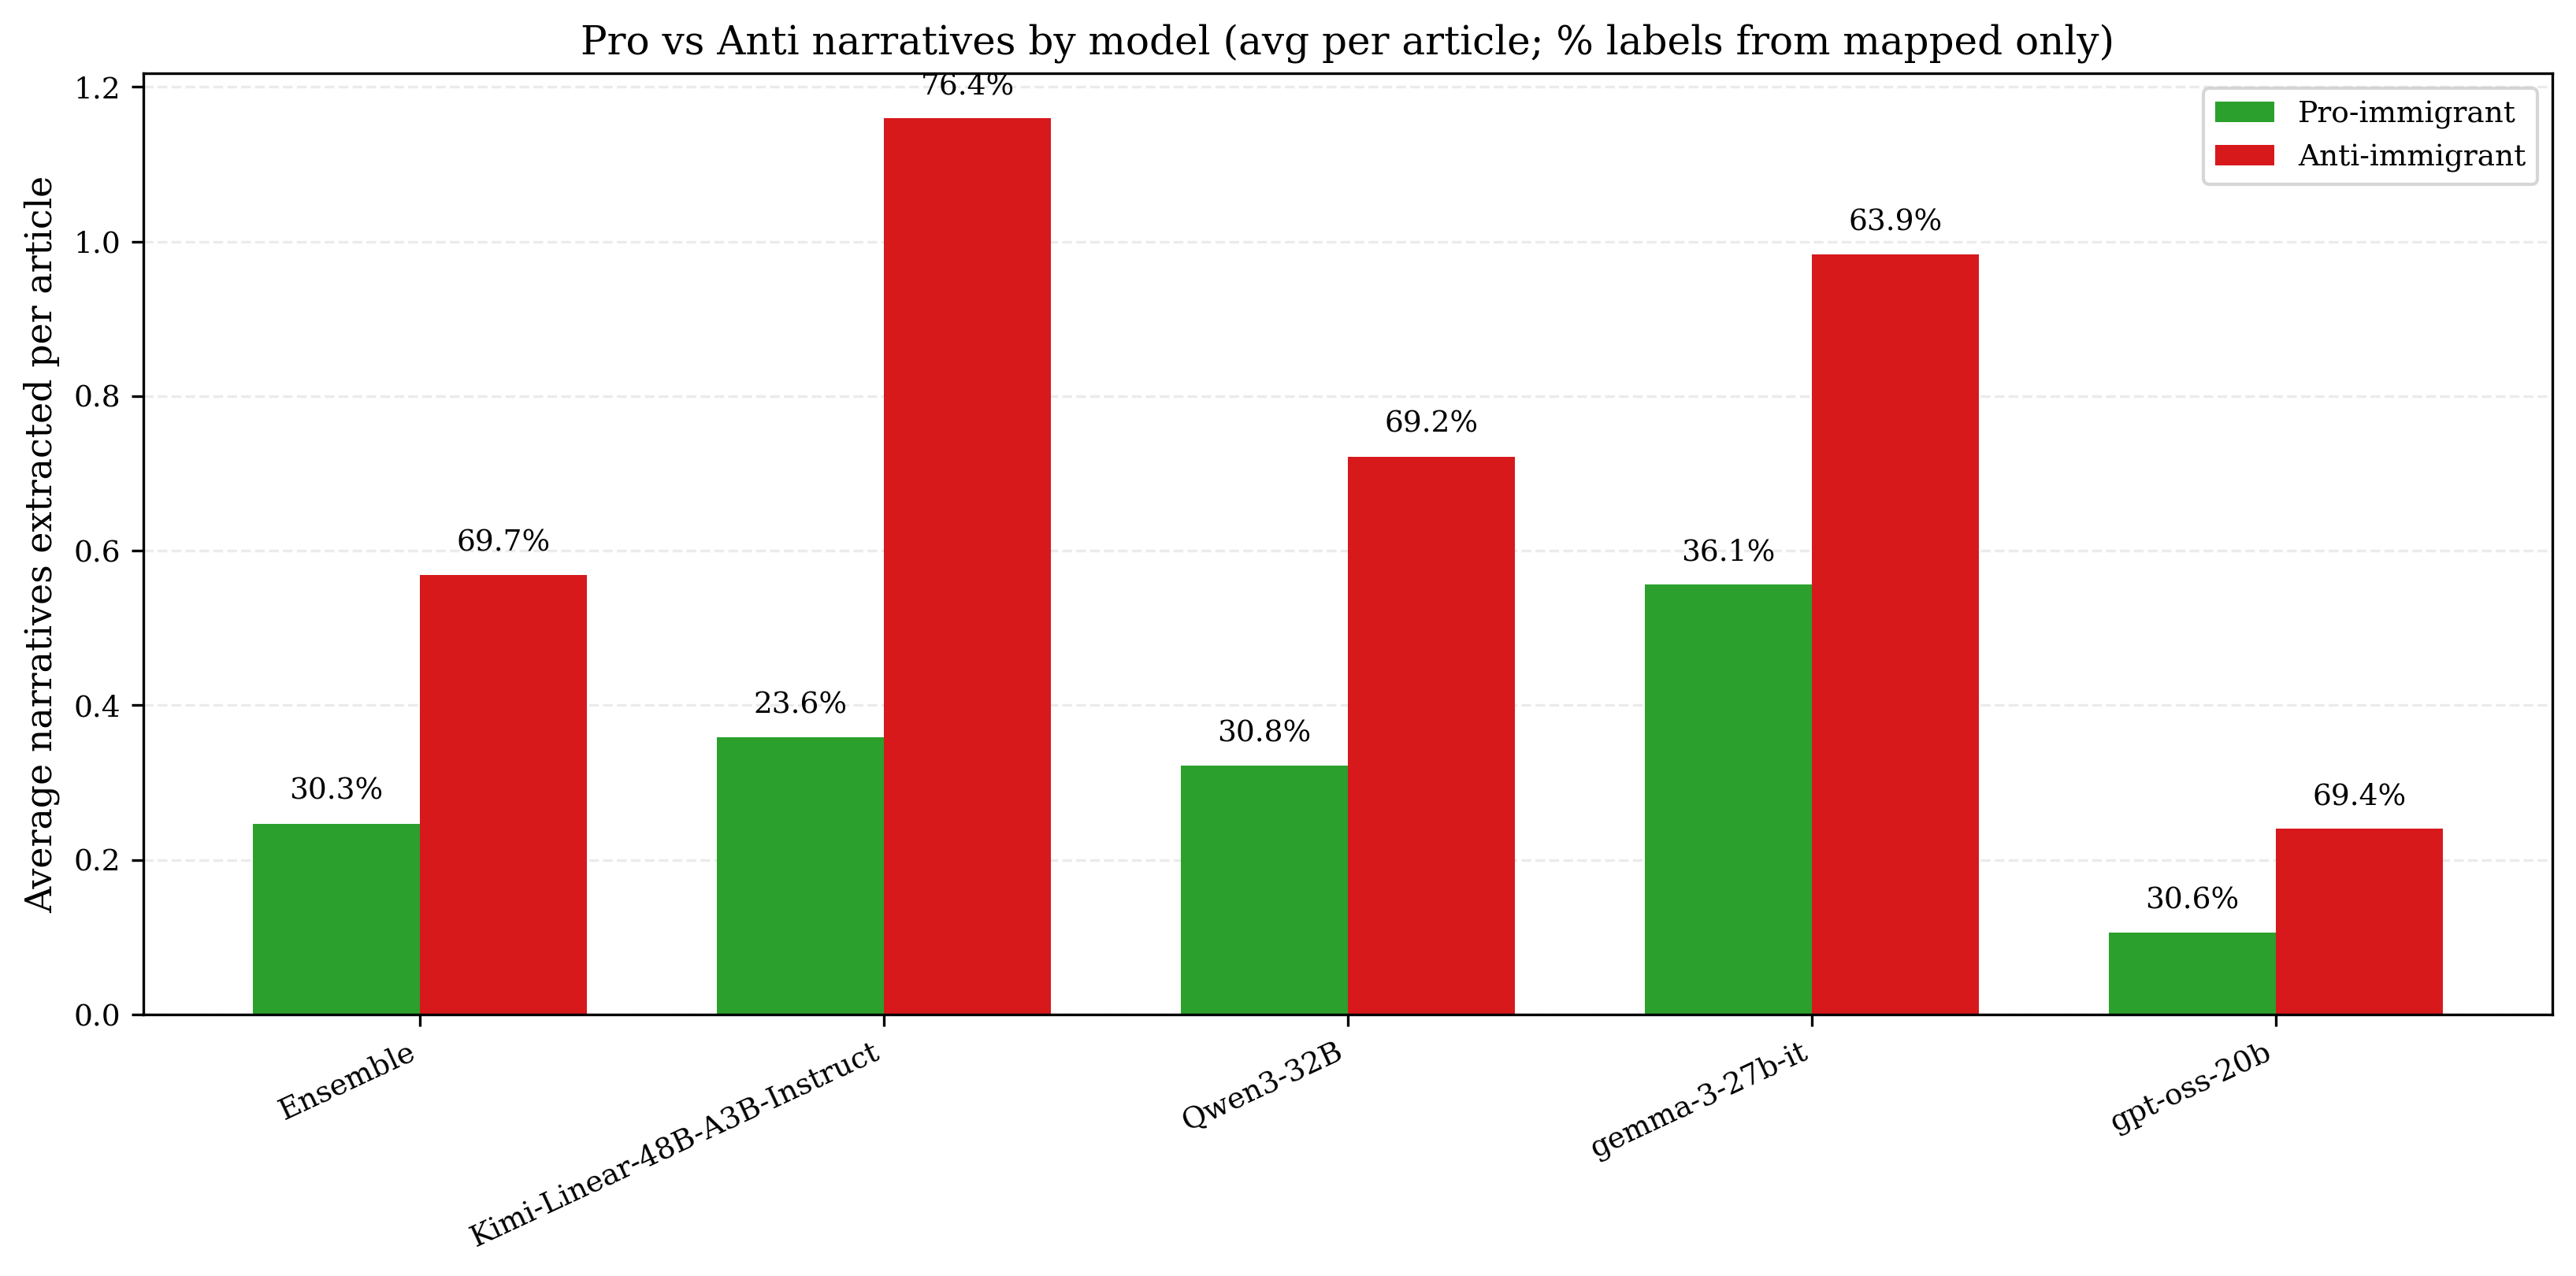

In [2]:
LLM_MODELS = [
    "gpt-oss-20b",
    "Qwen3-32B",
    "gemma-3-27b-it",
    "Kimi-Linear-48B-A3B-Instruct",
    "Ensemble",
]


import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from taxonomy.meso_narratives_revision_2 import mesoNarratives

# --- Helpers ---
def _norm_text(s: str) -> str:
    if s is None:
        return ""
    s = str(s).strip().lower()
    s = re.sub(r"\s+", " ", s)
    return s

def build_meso_to_stance_map(taxonomy_dict: dict) -> dict:
    """
    Returns mapping: normalized meso narrative -> 'pro-migrant'/'anti-migrant'/None
    None = ambiguous or invalid label.
    """
    allowed = {"pro-migrant", "anti-migrant"}
    tmp = {}

    for _, items in taxonomy_dict.items():
        if not isinstance(items, list):
            continue
        for item in items:
            if not (isinstance(item, list) and len(item) >= 2):
                continue
            meso_text, stance = item[0], item[1]
            key = _norm_text(meso_text)
            stance = _norm_text(stance)
            if not key:
                continue
            if stance not in allowed:
                tmp.setdefault(key, set()).add(None)
            else:
                tmp.setdefault(key, set()).add(stance)

    out = {}
    for k, stances in tmp.items():
        valid = {s for s in stances if s in allowed}
        out[k] = list(valid)[0] if len(valid) == 1 else None  # conflict => None
    return out

def pro_anti_breakdown_by_model(meso_df: pd.DataFrame, include_ensemble: bool = False):
    required = {"model", "meso_narrative", "count"}
    missing = required - set(meso_df.columns)
    if missing:
        raise ValueError(f"meso_df missing columns: {missing}")

    df = meso_df.copy()
    if not include_ensemble:
        df = df[df["model"] != "Ensemble"].copy()

    stance_map = build_meso_to_stance_map(mesoNarratives)

    df["meso_key"] = df["meso_narrative"].map(_norm_text)
    df["stance_raw"] = df["meso_key"].map(stance_map)  # can be NaN/None
    df["stance_bin"] = df["stance_raw"].map({
        "pro-migrant": "Pro-immigrant",
        "anti-migrant": "Anti-immigrant"
    })

    # mapped only (exclude null/unknown from percentages)
    mapped = df[df["stance_bin"].notna()].copy()
    unmapped = df[df["stance_bin"].isna()].copy()

    mapped_counts = (
        mapped.groupby(["model", "stance_bin"], as_index=False)["count"].sum()
    )
    mapped_totals = (
        mapped.groupby("model", as_index=False)["count"].sum()
        .rename(columns={"count": "mapped_count"})
    )

    breakdown = mapped_counts.merge(mapped_totals, on="model", how="left")
    breakdown["pct"] = 100 * breakdown["count"] / breakdown["mapped_count"]

    # summary table
    pivot_pct = (
        breakdown.pivot(index="model", columns="stance_bin", values="pct")
        .reset_index()
        .fillna(0)
    )

    unmapped_counts = (
        unmapped.groupby("model", as_index=False)["count"].sum()
        .rename(columns={"count": "unmapped_count"})
    )
    total_counts = (
        df.groupby("model", as_index=False)["count"].sum()
        .rename(columns={"count": "all_count"})
    )

    summary = (
        total_counts.merge(mapped_totals, on="model", how="left")
        .merge(unmapped_counts, on="model", how="left")
        .merge(pivot_pct, on="model", how="left")
        .fillna(0)
    )

    summary["excluded_share_%"] = np.where(
        summary["all_count"] > 0,
        100 * summary["unmapped_count"] / summary["all_count"],
        0
    )

    # Ensure columns exist
    for c in ["Pro-immigrant", "Anti-immigrant"]:
        if c not in summary.columns:
            summary[c] = 0.0

    return summary.sort_values("model"), breakdown

# --- Run ---
meso_slice = meso_df[
    (meso_df["version"] == 2) &
    (~meso_df["source_domain"].str.contains("UK Parliament", na=False))
].copy()

summary_df, long_df = pro_anti_breakdown_by_model(meso_slice, include_ensemble=True)

def article_counts_from_stance(stance_df: pd.DataFrame, meso_slice: pd.DataFrame) -> pd.DataFrame:
    """
    Use stance aggregates as article denominator:
    each article contributes once to stance, so summed stance counts ~= #articles.
    Filters are aligned to meso_slice (model, source_domain, month range).
    """
    if stance_df.empty:
        return pd.DataFrame(columns=["model", "article_count"])

    s = stance_df.copy()
    s = s[s["model"].isin(meso_slice["model"].unique())]

    if "source_domain" in s.columns and "source_domain" in meso_slice.columns:
        doms = meso_slice["source_domain"].dropna().unique().tolist()
        s = s[s["source_domain"].isin(doms)]

    if "month" in s.columns and "month" in meso_slice.columns:
        min_m = meso_slice["month"].min()
        max_m = meso_slice["month"].max()
        if pd.notna(min_m) and pd.notna(max_m):
            s = s[(s["month"] >= min_m) & (s["month"] <= max_m)]

    out = (
        s.groupby("model", as_index=False)["count"]
        .sum()
        .rename(columns={"count": "article_count"})
    )
    return out

article_df = article_counts_from_stance(stance_df, meso_slice)
summary_df = summary_df.merge(article_df, on="model", how="left").fillna({"article_count": 0})

print("Pro vs Anti breakdown by model (mapped-only %; per-article denominator from stance):")
print(
    summary_df[
        ["model", "Pro-immigrant", "Anti-immigrant", "mapped_count", "unmapped_count", "excluded_share_%", "article_count"]
    ].sort_values("model")
)

# --- Plot: paired bars per model (average narratives/article), with % labels on top ---
plot_models = summary_df["model"].sort_values().tolist()

plot_long = long_df.copy()
plot_long = plot_long[plot_long["model"].isin(plot_models)]

count_pivot = (
    plot_long.pivot_table(index="model", columns="stance_bin", values="count", aggfunc="sum", fill_value=0)
    .reindex(plot_models, fill_value=0)
)
pct_pivot = (
    plot_long.pivot_table(index="model", columns="stance_bin", values="pct", aggfunc="sum", fill_value=0)
    .reindex(plot_models, fill_value=0)
)

for c in ["Pro-immigrant", "Anti-immigrant"]:
    if c not in count_pivot.columns:
        count_pivot[c] = 0
    if c not in pct_pivot.columns:
        pct_pivot[c] = 0.0

article_counts = (
    summary_df.set_index("model")["article_count"]
    .reindex(plot_models)
    .fillna(0)
    .values
)

pro_counts = count_pivot["Pro-immigrant"].values
anti_counts = count_pivot["Anti-immigrant"].values
pro_pcts = pct_pivot["Pro-immigrant"].values
anti_pcts = pct_pivot["Anti-immigrant"].values

pro_avg = np.where(article_counts > 0, pro_counts / article_counts, np.nan)
anti_avg = np.where(article_counts > 0, anti_counts / article_counts, np.nan)

x = np.arange(len(plot_models))
w = 0.36

fig, ax = plt.subplots(figsize=(11, 5.5))

bars_pro = ax.bar(x - w/2, pro_avg, width=w, color="#2ca02c", label="Pro-immigrant")
bars_anti = ax.bar(x + w/2, anti_avg, width=w, color="#d7191c", label="Anti-immigrant")

# Percentage labels on top of each bar (still mapped-only %)
finite_vals = np.r_[np.nan_to_num(pro_avg, nan=0.0), np.nan_to_num(anti_avg, nan=0.0)]
ymax = float(finite_vals.max()) if len(finite_vals) else 1.0
offset = max(0.005, ymax * 0.02)

for rect, pct in zip(bars_pro, pro_pcts):
    h = rect.get_height()
    if np.isfinite(h):
        ax.text(rect.get_x() + rect.get_width()/2, h + offset, f"{pct:.1f}%", ha="center", va="bottom", fontsize=9)

for rect, pct in zip(bars_anti, anti_pcts):
    h = rect.get_height()
    if np.isfinite(h):
        ax.text(rect.get_x() + rect.get_width()/2, h + offset, f"{pct:.1f}%", ha="center", va="bottom", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(plot_models, rotation=25, ha="right")
ax.set_ylabel("Average narratives extracted per article")
ax.set_title("Pro vs Anti narratives by model (avg per article; % labels from mapped only)")
ax.legend(frameon=True)
ax.grid(axis="y", alpha=0.25, linestyle="--")
ax.set_axisbelow(True)

plt.tight_layout()
out_fp = os.path.join(OUTPUT_DIR, "model_pro_vs_anti_barpairs_avg_per_article.png")
plt.savefig(out_fp, dpi=300, bbox_inches="tight")
print(f"Saved: {out_fp}")
plt.show()

## Model Agreement

In [4]:
import sqlite3
import os
import json
import re
import pandas as pd
import numpy as np
from sklearn.metrics import cohen_kappa_score
from collections import defaultdict
from dotenv import load_dotenv
from taxonomy.meso_narratives_revision_2 import mesoNarratives

# Load database path
load_dotenv()
DB_PATH = os.getenv("SQLITE_PATH")

MODELS = ['gpt-oss-20b', 'Qwen3-32B', 'gemma-3-27b-it', 'Kimi-Linear-48B-A3B-Instruct']

# --- MACROS FOR VERSION CONTROL & FILTERING ---
STANCE_VERSION = 1
THEMES_MESO_VERSION = 2
STANCE_SOURCE_TABLES = ["uk_parliament_contributions"]#, "articles"]
# ----------------------------------------------

# Base sources for all other non-filtered tasks
ALL_SOURCE_TABLES = ["articles", "uk_parliament_contributions", "us_congress_speech"]

# --- Helpers for Meso-Narrative Stances ---
def _norm_text(s: str) -> str:
    if s is None:
        return ""
    s = str(s).strip().lower()
    return re.sub(r"\s+", " ", s)

def build_meso_to_stance_map(taxonomy_dict: dict) -> dict:
    allowed = {"pro-migrant", "anti-migrant"}
    tmp = {}
    for _, items in taxonomy_dict.items():
        if not isinstance(items, list): continue
        for item in items:
            if not (isinstance(item, list) and len(item) >= 2): continue
            meso_text, stance = item[0], item[1]
            key = _norm_text(meso_text)
            stance = _norm_text(stance)
            if not key: continue
            if stance not in allowed:
                tmp.setdefault(key, set()).add(None)
            else:
                tmp.setdefault(key, set()).add(stance)
    out = {}
    for k, stances in tmp.items():
        valid = {s for s in stances if s in allowed}
        out[k] = list(valid)[0] if len(valid) == 1 else None
    return out

STANCE_MAP = build_meso_to_stance_map(mesoNarratives)

def safe_json_load(val):
    if not val:
        return None
    try:
        return json.loads(val)
    except Exception:
        return None

def fetch_annotations_by_version(conn, source_table: str, task: str, version: int):
    """
    Return one row per (article_id, model), keeping the latest created_at
    if duplicates exist for the same version.
    """
    sql = """
    with ranked as (
      select
        article_id, model, annotation_parsed,
        row_number() over (
          partition by article_id, model
          order by datetime(created_at) desc
        ) as rn
      from llm_annotations
      where source_table = ?
        and task = ?
        and version = ?
        and model in (?, ?, ?, ?)
    )
    select article_id, model, annotation_parsed
    from ranked
    where rn = 1
    """
    return conn.execute(sql, (source_table, task, version, *MODELS)).fetchall()

# 1. Fetch from Database
raw_annotations = defaultdict(lambda: defaultdict(dict))

with sqlite3.connect(DB_PATH) as conn:
    # 1a. Fetch Stances (Filtered by Macro)
    for source in STANCE_SOURCE_TABLES:
        try:
            rows = fetch_annotations_by_version(conn, source, "stance", STANCE_VERSION)
            for aid, model, parsed in rows:
                o = safe_json_load(parsed) or {}
                stance = str(o.get("stance", "")).strip().upper()
                if stance:
                    raw_annotations[(source, aid)]["stance"][model] = stance
        except sqlite3.OperationalError:
            pass
            
    # 1b. Fetch Themes and Meso Narratives (All standard sources)
    for source in ALL_SOURCE_TABLES:
        try:
            # Themes
            rows = fetch_annotations_by_version(conn, source, "themes", THEMES_MESO_VERSION)
            for aid, model, parsed in rows:
                arr = safe_json_load(parsed) or []
                if isinstance(arr, list):
                    themes_set = {f.strip() for f in arr if isinstance(f, str) and f.strip()}
                    raw_annotations[(source, aid)]["themes"][model] = list(themes_set)

            # Meso Narratives
            rows = fetch_annotations_by_version(conn, source, "meso", THEMES_MESO_VERSION)
            for aid, model, parsed in rows:
                arr = safe_json_load(parsed) or []
                if isinstance(arr, list):
                    meso_items = []
                    for o in arr:
                        if isinstance(o, dict):
                            theme = o.get("narrative theme")
                            mn = o.get("meso narrative")
                            if isinstance(theme, str) and theme.strip() and isinstance(mn, str) and mn.strip():
                                meso_items.append((theme.strip(), mn.strip()))
                    raw_annotations[(source, aid)]["meso"][model] = meso_items
        except sqlite3.OperationalError:
            pass 
from collections import Counter

# Extended models list for table iteration
EXTENDED_MODELS = MODELS + ['Ensemble']

# 2. Extract aligned matrices
def extract_aligned(task_type):
    aligned = []
    # Only keep articles where ALL 4 models generated an output for this task
    for key, tasks in raw_annotations.items():
        if task_type in tasks:
            task_dict = tasks[task_type]
            if all(m in task_dict for m in MODELS):
                row = {m: task_dict[m] for m in MODELS}
                
                # Dynamically calculate the Ensemble label to include in the validation matrix
                if task_type == 'stance':
                    stances = [task_dict[m] for m in MODELS]
                    c_open = stances.count("OPEN")
                    c_restrictive = stances.count("RESTRICTIVE")
                    c_neutral = stances.count("NEUTRAL")
                    c_irrelevant = stances.count("IRRELEVANT")
                    
                    counts = {
                        "OPEN": c_open,
                        "RESTRICTIVE": c_restrictive,
                        "NEUTRAL": c_neutral,
                        "IRRELEVANT": c_irrelevant,
                    }
                    
                    max_count = max(counts.values()) if counts else 0
                    winners = [label for label, count in counts.items() if count == max_count]
                    
                    if len(winners) == 1:
                        ensemble_val = winners[0]
                    # Tie-breaker logic mirroring the export notebooks
                    elif "OPEN" in winners and "RESTRICTIVE" in winners and c_open > 0 and c_restrictive > 0:
                        ensemble_val = "NEUTRAL"
                    else:
                        for label in ["IRRELEVANT", "NEUTRAL", "OPEN", "RESTRICTIVE"]:
                            if label in winners:
                                ensemble_val = label
                                break
                    row['Ensemble'] = ensemble_val
                
                elif task_type in ('themes', 'meso'):
                    all_items = []
                    for m in MODELS:
                        all_items.extend(task_dict[m])
                    counts = Counter(all_items)
                    # Ensemble requires agreement from at least 2 models
                    row['Ensemble'] = [item for item, count in counts.items() if count >= 2]
                
                aligned.append(row)
    return aligned

stance_data = extract_aligned("stance")
themes_data = extract_aligned("themes")
meso_data = extract_aligned("meso")

print(f"Items with full suite of {len(MODELS)} models: Stance: {len(stance_data)}, Themes: {len(themes_data)}, Meso: {len(meso_data)}\n")

# --- TABLE 1: Stance (Cohen's Kappa) ---
def compute_stance_table():
    df = pd.DataFrame(index=EXTENDED_MODELS, columns=EXTENDED_MODELS, dtype=float)
    arrays = {m: [row[m] for row in stance_data] for m in EXTENDED_MODELS}
    
    for i, m1 in enumerate(EXTENDED_MODELS):
        for j, m2 in enumerate(EXTENDED_MODELS):
            if i > j: # lower triangle
                kappa = cohen_kappa_score(arrays[m1], arrays[m2])
                df.loc[m1, m2] = round(kappa, 3)
            else:
                df.loc[m1, m2] = ""
    return df

# --- TABLE 2 & 3: Multi-label Asymmetric Agreement ---
def compute_asymmetric_agreement(data_list, is_meso=False):
    # columns for output tables
    cols = EXTENDED_MODELS + ["Avg per document"]
    if is_meso:
        cols += ["% Pro-immigrant", "% Anti-immigrant"]
        
    df = pd.DataFrame(index=EXTENDED_MODELS, columns=cols)
    n_docs = len(data_list)
    
    # Pre-calculate totals per model
    totals = {m: 0 for m in EXTENDED_MODELS}
    for row in data_list:
        for m in EXTENDED_MODELS:
            totals[m] += len(row[m])
            
    for i, m_row in enumerate(EXTENDED_MODELS):
        # Average per document
        avg_docs = totals[m_row] / n_docs if n_docs > 0 else 0
        df.loc[m_row, "Avg per document"] = f"{avg_docs:.1f}"
        
        # Cross-model agreement
        for j, m_col in enumerate(EXTENDED_MODELS):
            if i == j:
                df.loc[m_row, m_col] = "-"
                continue
                
            agreed = 0
            predicted = totals[m_row]
            
            for row_data in data_list:
                set_pred = set(row_data[m_row])
                set_col = set(row_data[m_col])
                agreed += len(set_pred.intersection(set_col))
                    
            pct = (agreed / predicted * 100) if predicted > 0 else 0
            df.loc[m_row, m_col] = f"{pct:.1f}%"

        # Production Distribution for Meso
        if is_meso:
            pro_count = 0
            anti_count = 0
            for row_data in data_list:
                for p in row_data[m_row]:
                    mapped_stance = STANCE_MAP.get(_norm_text(p[1]))
                    if mapped_stance == 'pro-migrant':
                        pro_count += 1
                    elif mapped_stance == 'anti-migrant':
                        anti_count += 1
            
            total_mapped = pro_count + anti_count
            if total_mapped > 0:
                df.loc[m_row, "% Pro-immigrant"] = f"{(pro_count / total_mapped * 100):.1f}%"
                df.loc[m_row, "% Anti-immigrant"] = f"{(anti_count / total_mapped * 100):.1f}%"
            else:
                df.loc[m_row, "% Pro-immigrant"] = "0.0%"
                df.loc[m_row, "% Anti-immigrant"] = "0.0%"

    return df

print("=== Table 1: Stance Agreement (Cohen's Kappa) ===")
display(compute_stance_table().fillna(""))

print("\n=== Table 2: Themes Agreement (%) ===")
print("Reads as: Of the themes predicted by [Row], [Column] agreed X%")
display(compute_asymmetric_agreement(themes_data, is_meso=False))

print("\n=== Table 3: Meso Narratives Agreement (%) ===")
print("Reads as: Of the meso narratives predicted by [Row], [Column] agreed X%")
display(compute_asymmetric_agreement(meso_data, is_meso=True))

Items with full suite of 4 models: Stance: 81153, Themes: 267264, Meso: 139858

=== Table 1: Stance Agreement (Cohen's Kappa) ===


/tmp/ipykernel_1235318/2446738738.py:205: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[m1, m2] = ""
/tmp/ipykernel_1235318/2446738738.py:205: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[m1, m2] = ""
/tmp/ipykernel_1235318/2446738738.py:205: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[m1, m2] = ""
/tmp/ipykernel_1235318/2446738738.py:205: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future ver

,gpt-oss-20b,Qwen3-32B,gemma-3-27b-it,Kimi-Linear-48B-A3B-Instruct,Ensemble
gpt-oss-20b,,,,,
Qwen3-32B,0.489,,,,
gemma-3-27b-it,0.418,0.532,,,
Kimi-Linear-48B-A3B-Instruct,0.464,0.518,0.562,,
Ensemble,0.627,0.713,0.642,0.71,



=== Table 2: Themes Agreement (%) ===
Reads as: Of the themes predicted by [Row], [Column] agreed X%


,gpt-oss-20b,Qwen3-32B,gemma-3-27b-it,Kimi-Linear-48B-A3B-Instruct,Ensemble,Avg per document
gpt-oss-20b,-,51.1%,59.2%,53.8%,74.8%,1.9
Qwen3-32B,31.9%,-,60.6%,50.8%,72.8%,3.1
gemma-3-27b-it,29.3%,48.0%,-,49.0%,68.2%,3.9
Kimi-Linear-48B-A3B-Instruct,25.6%,38.8%,47.2%,-,57.8%,4.0
Ensemble,45.5%,70.8%,83.8%,73.7%,-,3.1



=== Table 3: Meso Narratives Agreement (%) ===
Reads as: Of the meso narratives predicted by [Row], [Column] agreed X%


,gpt-oss-20b,Qwen3-32B,gemma-3-27b-it,Kimi-Linear-48B-A3B-Instruct,Ensemble,Avg per document,% Pro-immigrant,% Anti-immigrant
gpt-oss-20b,-,32.9%,37.9%,25.6%,56.3%,1.4,33.9%,66.1%
Qwen3-32B,12.7%,-,30.5%,19.7%,42.7%,3.5,32.7%,67.3%
gemma-3-27b-it,11.4%,23.8%,-,19.7%,39.1%,4.5,35.6%,64.4%
Kimi-Linear-48B-A3B-Instruct,7.6%,15.2%,19.5%,-,29.8%,4.5,24.1%,75.9%
Ensemble,32.4%,63.6%,74.7%,57.5%,-,2.4,32.2%,67.8%


# Human Evaluation

## Relevance

In [2]:
import pandas as pd
from sklearn.metrics import cohen_kappa_score

FILE_PATH = f"data/validation/sampled_data_4relevance_validation_completed.xlsx"
COL_GPT = "relevance_label_gpt_oss_20b"
COL_A1 = "annotator1_label"
COL_A2 = "annotator2_label"

pairs = [
    (COL_GPT, COL_A1, "gpt_vs_annotator1"),
    (COL_GPT, COL_A2, "gpt_vs_annotator2"),
    (COL_A1, COL_A2, "annotator1_vs_annotator2"),
]

def norm(x):
    if pd.isna(x):
        return pd.NA
    return str(x).strip().upper()

df = pd.read_excel(FILE_PATH)

# Optional: keep this only if you want table filtering
df = df[df["source_table"].isin(["articles"])]

for c in [COL_GPT, COL_A1, COL_A2]:
    df[c] = df[c].map(norm)

labels = sorted(set(df[COL_GPT].dropna()) | set(df[COL_A1].dropna()) | set(df[COL_A2].dropna()))

kappa_rows = []
for c1, c2, tag in pairs:
    d = df[[c1, c2]].dropna().copy()
    kappa = cohen_kappa_score(d[c1], d[c2], labels=labels)
    cm = pd.crosstab(d[c1], d[c2]).reindex(index=labels, columns=labels, fill_value=0)

    print(f"\n=== {tag} ===")
    print(f"n={len(d)} | kappa={kappa:.4f}")
    print(cm)

    kappa_rows.append({"comparison": tag, "n": len(d), "cohen_kappa": kappa})

kappa_df = pd.DataFrame(kappa_rows)
kappa_df


=== gpt_vs_annotator1 ===
n=100 | kappa=0.7098
annotator1_label             IRRELEVANT  RELEVANT
relevance_label_gpt_oss_20b                      
IRRELEVANT                           60        10
RELEVANT                              3        27

=== gpt_vs_annotator2 ===
n=100 | kappa=0.9524
annotator2_label             IRRELEVANT  RELEVANT
relevance_label_gpt_oss_20b                      
IRRELEVANT                           69         1
RELEVANT                              1        29

=== annotator1_vs_annotator2 ===
n=100 | kappa=0.6652
annotator2_label  IRRELEVANT  RELEVANT
annotator1_label                      
IRRELEVANT                59         4
RELEVANT                  11        26


,comparison,n,cohen_kappa
0,gpt_vs_annotator1,100,0.709821
1,gpt_vs_annotator2,100,0.952381
2,annotator1_vs_annotator2,100,0.665179


## Stance

In [5]:
import os
import pandas as pd
import numpy as np
import json
from sklearn.metrics import cohen_kappa_score
from dotenv import load_dotenv
from IPython.display import display

load_dotenv()
DATA_DIR = os.path.expanduser("./data/")

# --- MACROS ---
INCLUDED_ANNOTATORS = ['Vahid Ghafouri', 'Denis Kierans', 'Rob McNeil']
SOURCE_TABLES_INCLUDED = ['uk_parliament_contributions']#, 'articles']
# --------------

# 1. Load & clean Data
human_eval_stance_df = pd.read_csv(os.path.join(DATA_DIR, "validation/stance_validations_rows.csv"))

# Filter by source table (ensure the column exists in your CSV)
if 'source_table' in human_eval_stance_df.columns:
    human_eval_stance_df = human_eval_stance_df[human_eval_stance_df['source_table'].isin(SOURCE_TABLES_INCLUDED)]

human_eval_stance_df = human_eval_stance_df.dropna(subset=['user_stance']).copy()

# Normalize human stances and names
human_eval_stance_df['user_stance'] = human_eval_stance_df['user_stance'].astype(str).str.strip().str.upper()
human_eval_stance_df['user_name'] = human_eval_stance_df['user_name'].astype(str).str.strip()

# 2. Parse LLM stances
def parse_stances(val):
    if pd.isna(val): return {}
    try:
        if isinstance(val, str):
            if val.startswith('"') and val.endswith('"'): val = json.loads(val)
            return json.loads(val)
        return dict(val)
    except Exception:
        return {}

human_eval_stance_df['parsed_llms'] = human_eval_stance_df['llm_stances'].apply(parse_stances)

MODELS = ['gpt-oss-20b', 'Qwen3-32B', 'gemma-3-27b-it', 'Kimi-Linear-48B-A3B-Instruct']
for m in MODELS:
    human_eval_stance_df[m] = human_eval_stance_df['parsed_llms'].apply(
        lambda x: x.get(m, None) if isinstance(x, dict) else None
    )
    human_eval_stance_df[m] = human_eval_stance_df[m].astype(str).str.strip().str.upper()

human_eval_stance_df['ensemble_stance'] = human_eval_stance_df['ensemble_stance'].astype(str).str.strip().str.upper()

# 3. Setup unified Table
# Filter to only the included annotators
all_users_in_db = human_eval_stance_df['user_name'].dropna().unique().tolist()
users = [u for u in INCLUDED_ANNOTATORS if u in all_users_in_db]

bot_targets = MODELS + ['ensemble_stance']

# Define Columns: Support (N), 5 Bots, User columns
columns = ["Support (N)"] + bot_targets + users
unified_df = pd.DataFrame(index=users, columns=columns)

# 4. Calculate Scores
for row_user in users:
    # Get this user's base annotations
    row_user_df = human_eval_stance_df[human_eval_stance_df['user_name'] == row_user].set_index('article_id')
    unified_df.loc[row_user, "Support (N)"] = len(row_user_df)
    
    # Calculate agreement between row_user and all Bots
    for col_bot in bot_targets:
        valid_bot = row_user_df[(row_user_df['user_stance'] != 'NAN') & (row_user_df[col_bot] != 'NAN')]
        if len(valid_bot) > 0:
            kappa = cohen_kappa_score(valid_bot['user_stance'], valid_bot[col_bot])
            unified_df.loc[row_user, col_bot] = f"{kappa:.3f}"
        else:
            unified_df.loc[row_user, col_bot] = "-"
            
    # Calculate agreement between row_user and all Users (including themselves)
    for col_user in users:
        if row_user == col_user:
            unified_df.loc[row_user, col_user] = "1.000"
            continue
            
        col_user_df = human_eval_stance_df[human_eval_stance_df['user_name'] == col_user].set_index('article_id')
        
        # Inner join to overlap
        overlap = pd.concat([row_user_df['user_stance'], col_user_df['user_stance']], axis=1, join='inner')
        overlap.columns = [row_user, col_user]
        
        if len(overlap) > 0:
            kappa = cohen_kappa_score(overlap[row_user], overlap[col_user])
            unified_df.loc[row_user, col_user] = f"{kappa:.3f}"
        else:
            unified_df.loc[row_user, col_user] = "-"

print("=== Cohen's Kappa: Humans vs Models & Humans ===")
display(unified_df)

=== Cohen's Kappa: Humans vs Models & Humans ===


,Support (N),gpt-oss-20b,Qwen3-32B,gemma-3-27b-it,Kimi-Linear-48B-A3B-Instruct,ensemble_stance,Vahid Ghafouri,Denis Kierans,Rob McNeil
Vahid Ghafouri,49,0.520,0.510,0.679,0.667,0.706,1.000,0.784,0.625
Denis Kierans,48,0.429,0.725,0.672,0.660,0.735,0.784,1.000,0.745
Rob McNeil,46,0.479,0.579,0.598,0.511,0.587,0.625,0.745,1.000


## Narrative (Theme and Meso)

In [4]:
import os
import pandas as pd
import numpy as np
from scipy.stats import pearsonr
from dotenv import load_dotenv
from IPython.display import display

load_dotenv()
DATA_DIR = os.path.expanduser("./data/")

# --- MACROS ---
INCLUDED_ANNOTATORS = ['Vahid Ghafouri', 'Denis Kierans', 'Rob McNeil']
# --------------

# 1. Load & clean Data
human_eval_narrative_df = pd.read_csv(os.path.join(DATA_DIR, "validation/narrative_validations_rows.csv"))

# Drop null scores and standardise names
human_eval_narrative_df = human_eval_narrative_df.dropna(subset=['score_theme', 'score_meso', 'user_name'])
human_eval_narrative_df['user_name'] = human_eval_narrative_df['user_name'].astype(str).str.strip()

# Filter to only the included annotators
all_users_in_db = human_eval_narrative_df['user_name'].unique().tolist()
users = [u for u in INCLUDED_ANNOTATORS if u in all_users_in_db]

models = human_eval_narrative_df['model'].unique().tolist()
bot_targets = models + ["Ensemble"]

columns = ["Support (N)"] + bot_targets + users
unified_df = pd.DataFrame(index=users, columns=columns)

# Calculate Ensemble Members based on >=2 models proposing them
theme_model_counts = human_eval_narrative_df.groupby(['article_id', 'theme'])['model'].nunique().reset_index()
ensemble_themes = theme_model_counts[theme_model_counts['model'] >= 2][['article_id', 'theme']]

meso_model_counts = human_eval_narrative_df.groupby(['article_id', 'meso_narrative'])['model'].nunique().reset_index()
ensemble_mesos = meso_model_counts[meso_model_counts['model'] >= 2][['article_id', 'meso_narrative']]

for row_user in users:
    user_df = human_eval_narrative_df[human_eval_narrative_df['user_name'] == row_user]
    
    # Calculate Total Support for this user (safely deduplicated by article + model + target)
    n_themes = user_df.drop_duplicates(subset=['article_id', 'model', 'theme'])['score_theme'].notna().sum()
    n_mesos = user_df.drop_duplicates(subset=['article_id', 'model', 'meso_narrative'])['score_meso'].notna().sum()
    unified_df.loc[row_user, "Support (N)"] = f"{n_themes} - {n_mesos}"
    
    # --- 1. User vs. Models (Average Score) ---
    for col_bot in bot_targets:
        if col_bot == "Ensemble":
            bot_theme_df = pd.merge(user_df, ensemble_themes, on=['article_id', 'theme'], how='inner')
            bot_meso_df = pd.merge(user_df, ensemble_mesos, on=['article_id', 'meso_narrative'], how='inner')
        else:
            bot_df = user_df[user_df['model'] == col_bot]
            bot_theme_df = bot_df.copy()
            bot_meso_df = bot_df.copy()
            
        # Deduplicate to prevent repeated themes/mesos strictly skewing the Bot's average
        bot_theme_df = bot_theme_df.drop_duplicates(subset=['article_id', 'theme'])
        bot_meso_df = bot_meso_df.drop_duplicates(subset=['article_id', 'meso_narrative'])
        
        avg_theme = bot_theme_df['score_theme'].mean() if len(bot_theme_df) > 0 else np.nan
        avg_meso = bot_meso_df['score_meso'].mean() if len(bot_meso_df) > 0 else np.nan
        
        str_theme = f"{avg_theme:.2f}" if not np.isnan(avg_theme) else "N/A"
        str_meso = f"{avg_meso:.2f}" if not np.isnan(avg_meso) else "N/A"
        unified_df.loc[row_user, col_bot] = f"{str_theme} - {str_meso}"
            
    # --- 2. User vs. User (Pearson Correlation) ---
    for col_user in users:
        if row_user == col_user:
            unified_df.loc[row_user, col_user] = "1.00 - 1.00"
            continue
            
        col_user_df = human_eval_narrative_df[human_eval_narrative_df['user_name'] == col_user]
        
        # Merge on exact signature to map exactly where humans graded the SAME text fragment and output
        overlap = pd.merge(
            user_df, 
            col_user_df, 
            on=['article_id', 'model', 'theme', 'meso_narrative', 'text_fragment'],
            suffixes=('_row', '_col')
        )
        
        # Deduplicate the merged outputs ensuring we don't calculate R for the exact same theme multiple times 
        # (due to multiple text_fragments/meso_narratives assigned to it on that article)
        theme_overlap = overlap.drop_duplicates(subset=['article_id', 'model', 'theme'])
        meso_overlap = overlap.drop_duplicates(subset=['article_id', 'model', 'meso_narrative'])
        
        if len(theme_overlap) > 1:
            t_row, t_col = theme_overlap['score_theme_row'], theme_overlap['score_theme_col']
            corr_theme, _ = pearsonr(t_row, t_col) if (t_row.nunique() > 1 and t_col.nunique() > 1) else (np.nan, None)
            str_theme = f"{corr_theme:.2f}" if not np.isnan(corr_theme) else "N/A"
        else:
            str_theme = "-.00"
            
        if len(meso_overlap) > 1:
            m_row, m_col = meso_overlap['score_meso_row'], meso_overlap['score_meso_col']
            corr_meso, _ = pearsonr(m_row, m_col) if (m_row.nunique() > 1 and m_col.nunique() > 1) else (np.nan, None)
            str_meso = f"{corr_meso:.2f}" if not np.isnan(corr_meso) else "N/A"
        else:
            str_meso = "-.00"

        if str_theme == "-.00" and str_meso == "-.00":
            unified_df.loc[row_user, col_user] = "- - -"
        else:
            str_theme = str_theme if str_theme != "-.00" else "N/A"
            str_meso  = str_meso if str_meso != "-.00" else "N/A"
            unified_df.loc[row_user, col_user] = f"{str_theme} - {str_meso}"

print("=== Theme & Meso Evaluation (Avg Score) / Inter-Human (Pearson r) ===")
print("Format: [Theme] - [Meso Narrative]")
display(unified_df)

=== Theme & Meso Evaluation (Avg Score) / Inter-Human (Pearson r) ===
Format: [Theme] - [Meso Narrative]


,Support (N),gpt-oss-20b,Qwen3-32B,Kimi-Linear-48B-A3B-Instruct,gemma-3-27b-it,Ensemble,Vahid Ghafouri,Denis Kierans,Rob McNeil
Vahid Ghafouri,376 - 762,4.78 - 4.06,4.89 - 3.56,4.64 - 2.76,4.78 - 3.50,4.83 - 3.70,1.00 - 1.00,0.45 - 0.52,0.39 - 0.54
Denis Kierans,343 - 706,4.44 - 3.68,4.47 - 2.82,4.01 - 2.36,4.30 - 2.68,4.52 - 3.06,0.45 - 0.52,1.00 - 1.00,0.56 - 0.61
Rob McNeil,779 - 1633,4.69 - 4.11,4.68 - 3.75,4.23 - 2.71,4.67 - 3.70,4.72 - 3.79,0.39 - 0.54,0.56 - 0.61,1.00 - 1.00
